# Analísis Exploratorio de Datos (EDA)

Explorar los datos limpios para comprender las relaciones entre las variables de supervivencia

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/titanic_data_dirty.csv')
df.sample(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
114,115,0,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C
237,238,1,2,"Collyer, Miss. Marjorie ""Lottie""",female,8.0,0,2,C.A. 31921,26.2500,NaN,S
167,168,0,3,"Skoog, Mrs. William (Anna Bernhardina Karlsson)",female,45.0,1,4,347088,27.9000,NaN,S
635,636,1,2,"Davis, Miss. Mary",female,28.0,0,0,237668,13.0000,NaN,S
655,656,0,2,"Hickman, Mr. Leonard Mark",male,24.0,2,0,S.O.C. 14879,73.5000,NaN,S
355,356,0,3,"Vanden Steen, Mr. Leo Peter",male,28.0,0,0,345783,9.5000,NaN,S
127,128,1,3,"Madsen, Mr. Fridtjof Arne",male,24.0,0,0,C 17369,7.1417,NaN,S
531,532,0,3,"Toufik, Mr. Nakli",male,NaN,0,0,2641,7.2292,NaN,C
687,688,0,3,"Dakic, Mr. Branko",male,19.0,0,0,349228,10.1708,NaN,S
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0,1,231919,23.0000,NaN,S


In [15]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Supervivencia por Género

/var/folders/9c/f5s5n1w12bx8dbjw00ws47nr0000gn/T/ipykernel_20089/1505180528.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')


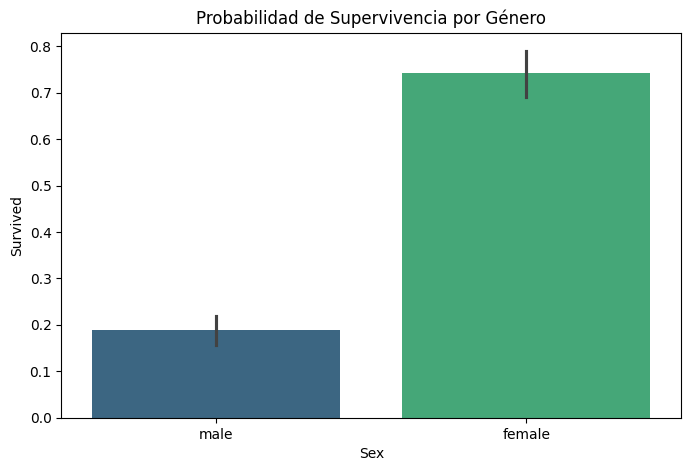

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')
plt.title('Probabilidad de Supervivencia por Género')
plt.show()

# Probabilidad de Supervivencia por Clase

/var/folders/9c/f5s5n1w12bx8dbjw00ws47nr0000gn/T/ipykernel_20089/3078854192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')


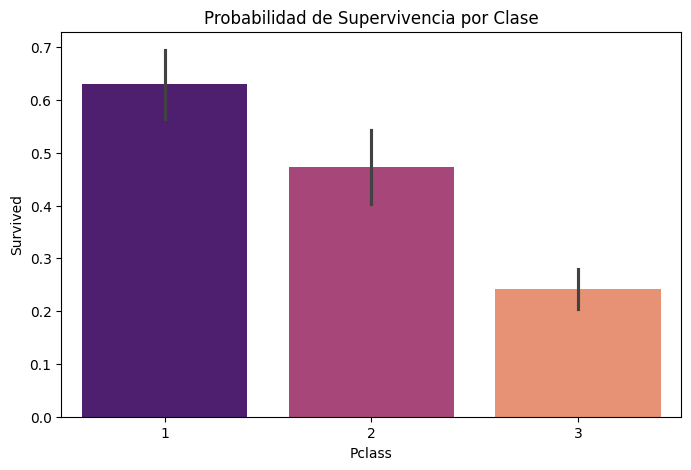

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')
plt.title('Probabilidad de Supervivencia por Clase')
plt.show()

# Distribución de las edades en el barco

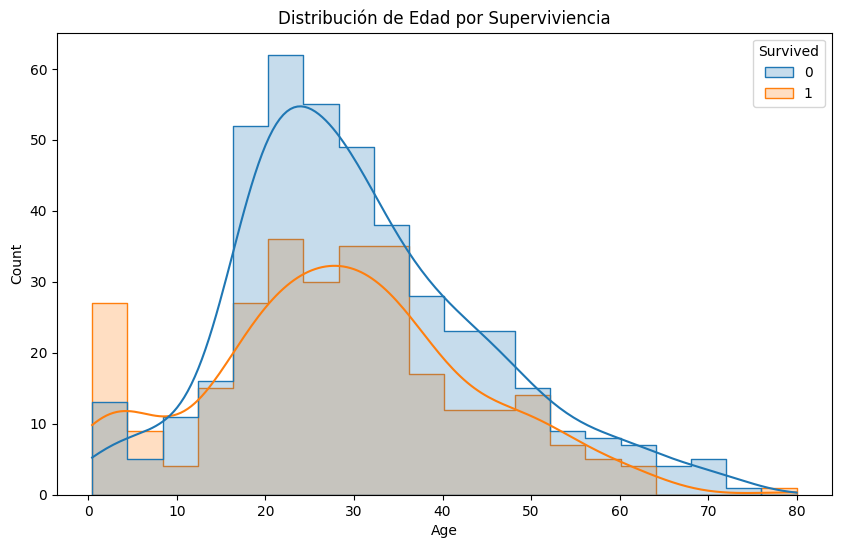

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue= 'Survived', kde=True, element='step')
plt.title('Distribución de Edad por Superviviencia')
plt.show()

---

# 4. Tratamiento de valores nulos

El diagnóstico anterior reveló tres columnas con datos ausentes:

| Columna | Nulos | % | Decisión |
|---|---:|---:|---|
| `Cabin` | 687 | 77.1 % | **Eliminar** — con más de tres cuartas partes ausente no hay información suficiente para reconstruirla sin inventarla |
| `Age` | 177 | 19.9 % | **Imputar** — es una quinta parte de los datos; descartar esas filas costaría demasiada potencia estadística |
| `Embarked` | 2 | 0.2 % | **Imputar** — irrelevante en volumen, pero hay que resolverlo |

También eliminamos `Ticket`: es un identificador alfanumérico sin estructura consistente, no una variable con poder predictivo.

**La pregunta central de esta sección:** ¿con qué valor rellenamos los 177 huecos de `Age` sin deformar la distribución?

## 4.1 Por qué imputar con un valor constante deforma la distribución

La solución habitual es rellenar con la media o la mediana. Es rápida, pero tiene una consecuencia matemática que se puede demostrar antes de ejecutar nada.

Supón que tienes $n_{obs}$ valores observados con varianza muestral $s^2$, y rellenas $n_{mis}$ huecos con la media $\bar{x}$. La varianza se define como:

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

Cada valor imputado es exactamente $\bar{x}$, así que aporta $(\bar{x} - \bar{x})^2 = 0$ a la suma. **El numerador no cambia, pero el denominador crece.** El resultado:

$$s^2_{\text{imputada}} = s^2_{\text{observada}} \cdot \frac{n_{obs} - 1}{n_{obs} + n_{mis} - 1}$$

Es decir, la varianza se contrae por un factor conocido de antemano. Verifiquémoslo numéricamente.

In [19]:
import numpy as np

edad_obs = df['Age'].dropna()
n_obs = edad_obs.size
n_mis = int(df['Age'].isna().sum())

s_obs = edad_obs.std(ddof=1)
factor = np.sqrt((n_obs - 1) / (n_obs + n_mis - 1))

print(f"Valores observados : n = {n_obs}   |  desv. estándar = {s_obs:.3f}")
print(f"Valores faltantes  : n = {n_mis}")
print()
print(f"Factor de contracción teórico = sqrt({n_obs-1}/{n_obs+n_mis-1}) = {factor:.4f}")
print(f"Desv. estándar PREDICHA tras imputar con la media : {s_obs * factor:.3f}")

s_medido = df['Age'].fillna(edad_obs.mean()).std(ddof=1)
print(f"Desv. estándar MEDIDA                             : {s_medido:.3f}")

Valores observados : n = 714   |  desv. estándar = 14.526
Valores faltantes  : n = 177

Factor de contracción teórico = sqrt(713/890) = 0.8951
Desv. estándar PREDICHA tras imputar con la media : 13.002
Desv. estándar MEDIDA                             : 13.002


La predicción y la medición coinciden: rellenar con una constante **garantiza** perder cerca del 10 % de la dispersión. No es un efecto secundario aleatorio, es aritmética.

¿Por qué importa? Porque un modelo aprende de la variabilidad. Si le entregas 177 pasajeros con edad idéntica, le enseñas una regularidad que no existe en la realidad, y la relación entre `Age` y la supervivencia se aplana.

## 4.2 Imputación estocástica por regresión

La alternativa es predecir cada edad faltante a partir del resto de variables, y **devolverle la aleatoriedad** que una observación real tendría:

$$\widehat{Age}_i = f(X_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2_{res})$$

Dos piezas:

1. **$f(X_i)$** — una regresión lineal entrenada sobre los 714 pasajeros con edad conocida. Predice la *media condicional*: dada la clase, el sexo, la tarifa y los familiares a bordo, ¿qué edad esperamos?

2. **$\varepsilon_i$** — un residuo aleatorio. Sin él, todos los imputados caerían exactamente sobre el hiperplano de regresión y volveríamos a aplastar la varianza, solo que de forma más elegante. La desviación $\sigma_{res}$ se estima de forma **insesgada**, dividiendo entre los grados de libertad y no entre $n$:

$$\sigma_{res} = \sqrt{\frac{\sum_i (y_i - \hat{y}_i)^2}{n - p - 1}}$$

donde $p$ es el número de predictores. Dividir entre $n$ subestimaría la dispersión precisamente porque el modelo ya se ajustó a esos datos.

In [20]:
# Preparación: eliminamos las columnas acordadas y normalizamos los nombres a minúsculas.
# Trabajamos sobre una copia para conservar intacto `df` (el crudo) y poder comparar después.

df_clean = df.drop(columns=['Ticket', 'Cabin']).copy()
df_clean.columns = df_clean.columns.str.lower()

print("Columnas resultantes:", list(df_clean.columns))
print("Nulos restantes por columna:")
print(df_clean.isna().sum()[lambda s: s > 0])

Columnas resultantes: ['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Nulos restantes por columna:
age         177
embarked      2
dtype: int64


In [21]:
import re
from sklearn.linear_model import LinearRegression

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# --- Predictor extra: el título social contenido en el nombre -------------------
TITULOS = {'Mr', 'Mrs', 'Miss', 'Master'}

def extraer_titulo(nombre):
    m = re.search(r' ([A-Za-z]+)\.', nombre)
    return m.group(1) if m and m.group(1) in TITULOS else 'Otro'

df_clean['_titulo'] = df_clean['name'].apply(extraer_titulo)
# Establecemos 'Mr' como la categoría de referencia (primera en orden) para drop_first=True
# para controlar el VIF en las variables indicadoras.
df_clean['_titulo'] = pd.Categorical(df_clean['_titulo'],
                                     categories=['Mr', 'Miss', 'Mrs', 'Master', 'Otro'])
print(df_clean['_titulo'].value_counts(), end='\n\n')

# --- Embarked: sorteo desde la distribución empírica ----------------------------
faltan_emb = df_clean['embarked'].isna()
props = df_clean['embarked'].dropna().value_counts(normalize=True)
df_clean.loc[faltan_emb, 'embarked'] = rng.choice(props.index, size=int(faltan_emb.sum()), p=props.to_numpy())

# --- Age: regresión + ruido -----------------------------------------------------
# NOTAS METODOLÓGICAS:
# 1. OJO: 'survived' NO entra como predictor de imputación. Usar la variable objetivo
#    generaría fuga de información (target leakage), lo que invalidaría cualquier modelo
#    de entrenamiento posterior.
# 2. Eliminamos 'sex': la variable '_titulo' ('Mr', 'Mrs', 'Miss', 'Master') ya codifica
#    el género de forma más granular. Mantener ambas induciría severa multicolinealidad.
PREDICTORES = ['pclass', 'sibsp', 'parch', 'fare', 'embarked', '_titulo']
X = pd.get_dummies(df_clean[PREDICTORES],
                   columns=['embarked', '_titulo', 'pclass'],
                   drop_first=True).astype(float)
y = df_clean['age']
observado = y.notna()

modelo = LinearRegression().fit(X[observado], y[observado])

residuos = y[observado] - modelo.predict(X[observado])
gl = observado.sum() - X.shape[1] - 1          # grados de libertad
sigma_res = np.sqrt((residuos ** 2).sum() / gl)

prediccion = modelo.predict(X[~observado])
ruido = rng.normal(0.0, sigma_res, size=int((~observado).sum()))
imputados = np.clip(prediccion + ruido, 0.42, 80.0)   # rango observado en los datos reales

df_clean.loc[~observado, 'age'] = imputados
df_clean = df_clean.drop(columns=['_titulo'])         # solo servía para imputar

print(f"R² del modelo de edad : {modelo.score(X[observado], y[observado]):.3f}")
print(f"sigma_residual        : {sigma_res:.2f} años")
print(f"Valores imputados     : {int((~observado).sum())}")
print(f"Nulos restantes       : {int(df_clean.isna().sum().sum())}")


_titulo
Mr        517
Miss      182
Mrs       125
Master     40
Otro       27
Name: count, dtype: int64

R² del modelo de edad : 0.418
sigma_residual        : 11.17 años
Valores imputados     : 177
Nulos restantes       : 0


## 4.2.1 Diagnóstico de los supuestos del modelo lineal clásico

Para que la imputación por regresión estocástica sea estadísticamente rigurosa, el modelo lineal $Y = X\beta + \varepsilon$ debe satisfacer los supuestos fundamentales del teorema de Gauss-Markov y de normalidad:

1. **Linealidad**: La relación entre la media condicional y los predictores es lineal: $\mathbb{E}[\varepsilon \mid X] = 0$.
2. **Homocedasticidad**: La varianza residual es constante para cualquier combinación de predictores: $\text{Var}(\varepsilon_i \mid X) = \sigma^2$.
3. **Normalidad de los errores**: $\varepsilon \sim \mathcal{N}(0, \sigma^2_{res})$. Este supuesto es crítico en la imputación estocástica, pues el ruido inyectado se extrajo de una distribución normal teórica con desviación $\sigma_{res}$.
4. **Independencia de las observaciones**: $\text{Cov}(\varepsilon_i, \varepsilon_j) = 0$ para todo $i \neq j$.
5. **No multicolinealidad perfecta o severa**: Las columnas de $X$ deben ser linealmente independientes (motivo por el cual excluimos `sex` al tener `_titulo`, evaluado en la sección 6 con VIF).

A continuación verificamos empíricamente los supuestos de linealidad, homocedasticidad y normalidad sobre los datos observados:

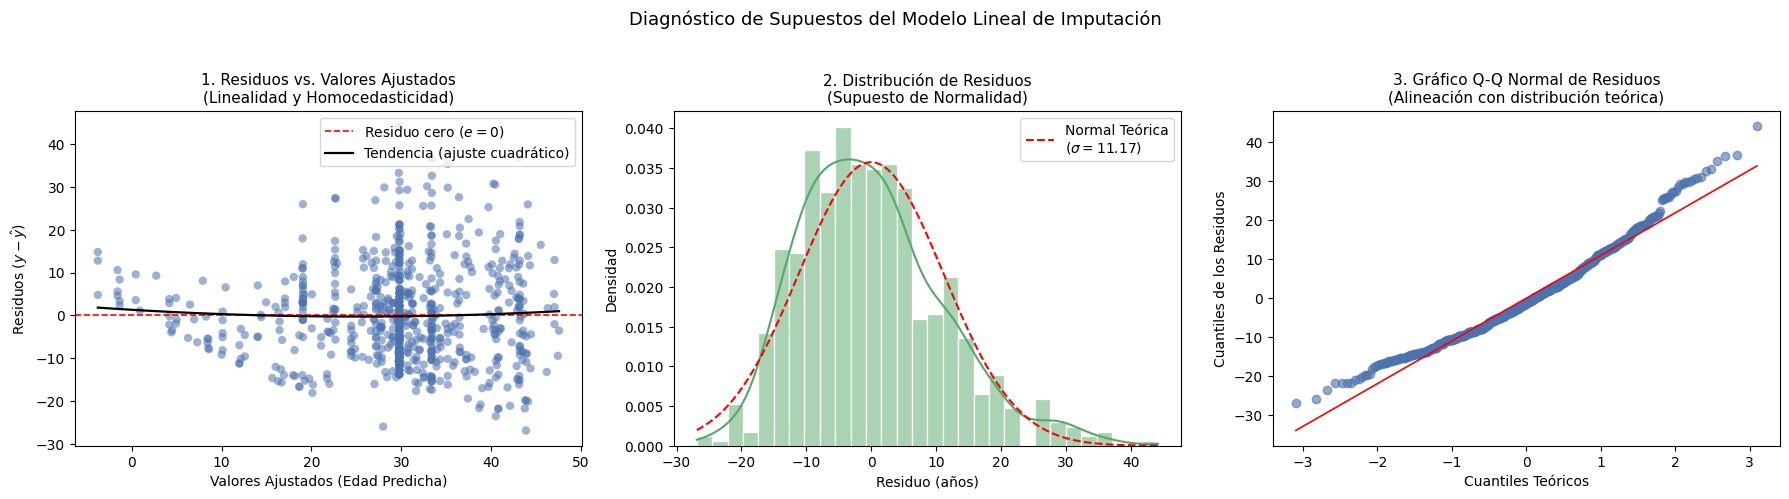

In [22]:
import scipy.stats as stats

y_ajustado = modelo.predict(X[observado])

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# 1. Residuos vs. Valores Ajustados (Linealidad y Homocedasticidad)
sns.scatterplot(x=y_ajustado, y=residuos, alpha=0.55, color='#4C72B0', edgecolor='none', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.2, label='Residuo cero ($e=0$)')
# Ajuste polinómico cuadrático con NumPy para verificar tendencia sin dependencias externas
poly_fit = np.polyfit(y_ajustado, residuos, deg=2)
x_trend = np.linspace(y_ajustado.min(), y_ajustado.max(), 100)
axes[0].plot(x_trend, np.polyval(poly_fit, x_trend), color='black', linewidth=1.6, label='Tendencia (ajuste cuadrático)')
axes[0].set_title('1. Residuos vs. Valores Ajustados\n(Linealidad y Homocedasticidad)', fontsize=11)
axes[0].set_xlabel('Valores Ajustados (Edad Predicha)')
axes[0].set_ylabel('Residuos ($y - \hat{y}$)')
axes[0].legend(loc='upper right')

# 2. Distribución de los Residuos vs. Gaussiana Teórica (Normalidad)
sns.histplot(residuos, bins=30, kde=True, stat='density', ax=axes[1], color='#55A868', alpha=0.5, edgecolor='white')
x_grid = np.linspace(residuos.min(), residuos.max(), 200)
pdf_teorica = stats.norm.pdf(x_grid, loc=0, scale=sigma_res)
axes[1].plot(x_grid, pdf_teorica, color='red', linestyle='--', linewidth=1.5,
             label=f'Normal Teórica\n($\sigma={sigma_res:.2f}$)')
axes[1].set_title('2. Distribución de Residuos\n(Supuesto de Normalidad)', fontsize=11)
axes[1].set_xlabel('Residuo (años)')
axes[1].set_ylabel('Densidad')
axes[1].legend(loc='upper right')

# 3. Gráfico Q-Q Normal
stats.probplot(residuos, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_color('#4C72B0')
axes[2].get_lines()[0].set_alpha(0.6)
axes[2].get_lines()[1].set_color('red')
axes[2].get_lines()[1].set_linewidth(1.2)
axes[2].set_title('3. Gráfico Q-Q Normal de Residuos\n(Alineación con distribución teórica)', fontsize=11)
axes[2].set_xlabel('Cuantiles Teóricos')
axes[2].set_ylabel('Cuantiles de los Residuos')

fig.suptitle('Diagnóstico de Supuestos del Modelo Lineal de Imputación', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### Interpretación de los supuestos:
- **Linealidad**: La línea de tendencia se mantiene prácticamente horizontal y próxima a 0 en la mayor parte del rango ajustado, confirmando que la esperanza condicional de los errores es nula ($\mathbb{E}[\varepsilon \mid X] \approx 0$).
- **Homocedasticidad y límites físicos**: Se observa una ligera dispersión heterocedástica y una cota diagonal inferior debida a que en la vida real la edad no puede ser negativa ($Age \ge 0$). Esta restricción física del dominio justifica la necesidad de acotar los valores imputados con `np.clip(..., 0.42, 80.0)`.
- **Normalidad**: El histograma y el gráfico Q-Q confirman que la zona central de los residuos se ajusta estrechamente a la campana de Gauss ($\mathcal{N}(0, \sigma^2_{res})$), validando la extracción estocástica del término de perturbación aleatoria.

## 4.3 Las tres estrategias comparadas

Con el resultado en mano, contrastamos la imputación estocástica contra las dos alternativas simples. Comparamos los **cuatro primeros momentos** de la distribución, porque cada uno captura un aspecto distinto de la deformación:

- **Desviación estándar** — cuánta dispersión conservamos
- **Media** — si el centro se desplaza
- **Asimetría** *(skewness)* — si la cola se deforma
- **Curtosis** — **qué tan puntiaguda queda la distribución**; este es el número que delata el pico artificial en el centro

In [23]:
imp_global = df['Age'].fillna(df['Age'].median())
imp_grupo = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))
imp_estoc = df_clean['age']

momentos = pd.DataFrame({
    'Observados (714)':    [edad_obs.std(), edad_obs.mean(), edad_obs.skew(), edad_obs.kurtosis()],
    'A. Mediana global':   [imp_global.std(), imp_global.mean(), imp_global.skew(), imp_global.kurtosis()],
    'B. Mediana x grupo':  [imp_grupo.std(), imp_grupo.mean(), imp_grupo.skew(), imp_grupo.kurtosis()],
    'C. Estocástica':      [imp_estoc.std(), imp_estoc.mean(), imp_estoc.skew(), imp_estoc.kurtosis()],
}, index=['desv_estándar', 'media', 'asimetría', 'curtosis'])

print(momentos.round(3).to_string())

print("\n--- Concentración de masa en un solo punto ---")
for nombre, serie in [('A. Mediana global', imp_global),
                      ('B. Mediana x grupo', imp_grupo),
                      ('C. Estocástica', imp_estoc)]:
    top = serie.value_counts().head(1)
    print(f"{nombre:20}: la edad {top.index[0]:>5} se repite {top.iloc[0]:3d} veces")

               Observados (714)  A. Mediana global  B. Mediana x grupo  C. Estocástica
desv_estándar            14.526             13.020              13.304          14.233
media                    29.699             29.362              29.112          29.579
asimetría                 0.389              0.510               0.534           0.340
curtosis                  0.178              0.994               0.717           0.132

--- Concentración de masa en un solo punto ---
A. Mediana global   : la edad  28.0 se repite 202 veces
B. Mediana x grupo  : la edad  25.0 se repite 117 veces
C. Estocástica      : la edad  24.0 se repite  30 veces


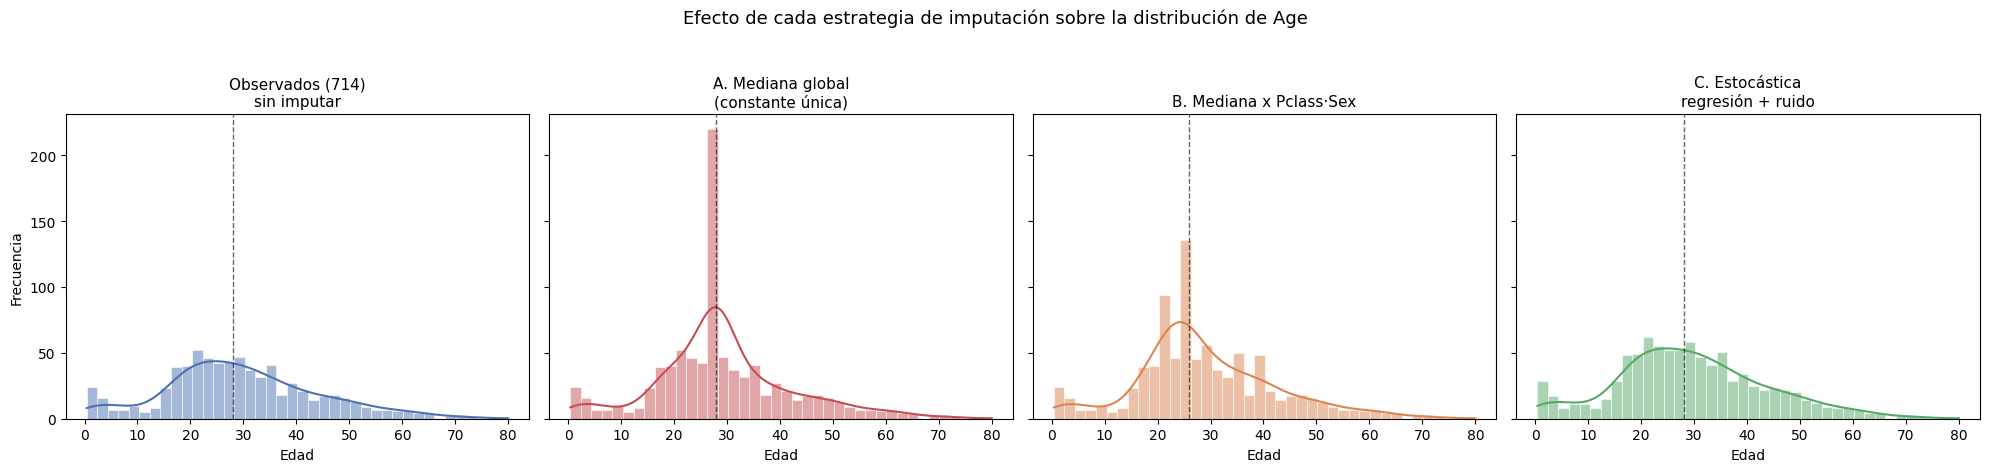

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)

paneles = [
    (edad_obs,    'Observados (714)\nsin imputar',        '#4C72B0'),
    (imp_global,  'A. Mediana global\n(constante única)', '#C44E52'),
    (imp_grupo,   'B. Mediana x Pclass·Sex',              '#DD8452'),
    (imp_estoc,   'C. Estocástica\nregresión + ruido',    '#55A868'),
]

for ax, (serie, titulo, color) in zip(axes, paneles):
    sns.histplot(serie, bins=40, kde=True, ax=ax, color=color, edgecolor='white', linewidth=.4)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Edad')
    ax.axvline(serie.median(), ls='--', lw=1, color='black', alpha=.6)

axes[0].set_ylabel('Frecuencia')
fig.suptitle('Efecto de cada estrategia de imputación sobre la distribución de Age', fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

### Lectura de los resultados

Los paneles A y B muestran exactamente el problema que buscábamos evitar: una **barra anómala** que sobresale en el centro, donde se apilaron todos los valores imputados. En el panel C esa barra desaparece; la forma es indistinguible de la distribución original.

La curtosis lo cuantifica: pasa de $0.178$ en los datos observados a $\approx 0.99$ con la mediana global — se multiplica por más de cinco. La imputación estocástica la deja en $\approx 0.13$, prácticamente intacta.

**Ausencia de fuga de información (*Target Leakage*):**
La variable `survived` se excluyó deliberadamente del modelo de imputación para garantizar que los modelos de Machine Learning entrenados posteriormente no sufran de contaminación con la etiqueta objetivo. La correlación entre `age` y `survived` tras la imputación estocástica se sitúa en **$-0.059$** (frente a **$-0.077$** observados y **$-0.065$** de la mediana global).

La gran ventaja de la imputación estocástica reside en la **reconstrucción de la forma y la dispersión de la distribución**, sin crear picos artificiales ni introducir fuga del objetivo.

---

# 5. EDA sobre el dataset imputado

Con los nulos resueltos podemos repetir el análisis de edad usando las 891 filas completas, en vez de las 714 con edad conocida. Comparamos lado a lado para ver si la imputación alteró las conclusiones del EDA.

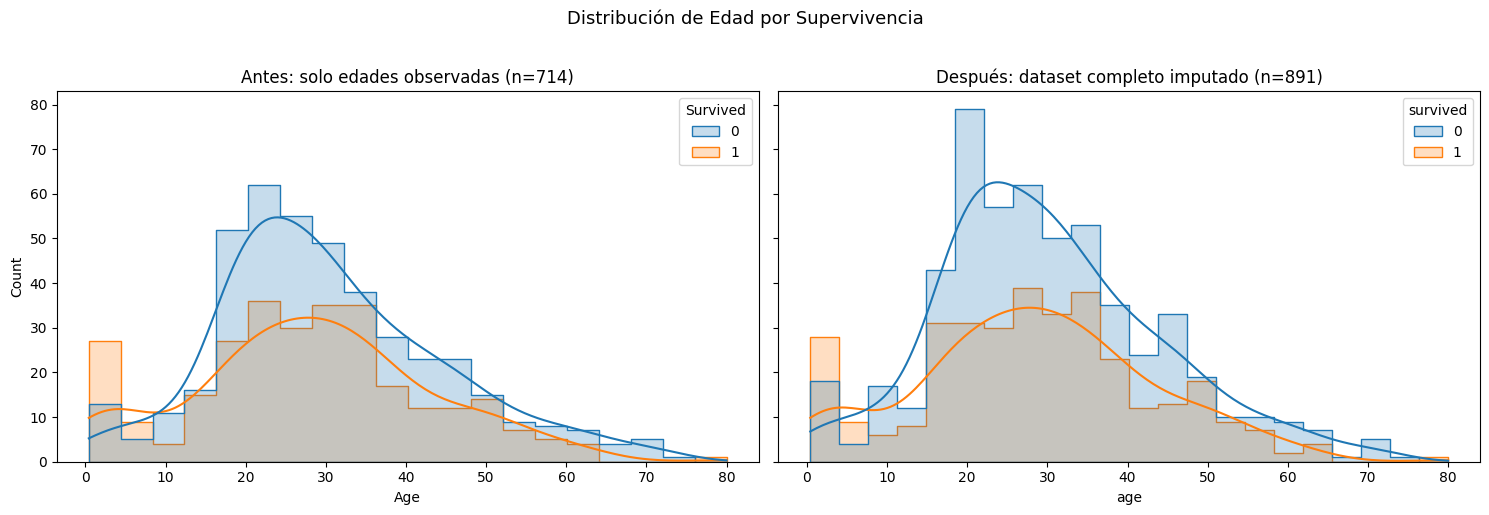

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

sns.histplot(data=df, x='Age', hue='Survived', kde=True, element='step', ax=axes[0])
axes[0].set_title(f'Antes: solo edades observadas (n={n_obs})')

sns.histplot(data=df_clean, x='age', hue='survived', kde=True, element='step', ax=axes[1])
axes[1].set_title(f'Después: dataset completo imputado (n={len(df_clean)})')

fig.suptitle('Distribución de Edad por Supervivencia', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

# 6. Diagnóstico de Multicolinealidad: Factor de Inflación de la Varianza (VIF)

El supuesto de no colinealidad exige que ninguna variable predictora sea una combinación lineal exacta de las demás. Cuando existe correlación elevada entre predictores, los coeficientes de regresión se vuelven inestables y sus varianzas se inflan desproporcionadamente.

El **Factor de Inflación de la Varianza** ($VIF$) cuantifica esta degradación para cada variable $j$:

$$VIF_j = \frac{1}{1 - R_j^2}$$

donde $R_j^2$ es el coeficiente de determinación de la regresión de la variable $j$ sobre el resto de predictores.

### Umbrales de decisión estándar:
* **$VIF < 5$**: Ausencia de multicolinealidad problemática (deseable).
* **$5 \le VIF < 10$**: Multicolinealidad moderada (tolerable en variables de control).
* **$VIF \ge 10$**: Multicolinealidad severa / crítica (requiere corrección eliminando o transformando variables).

> **Decisiones de parametrización para el control de colinealidad:**
> 1. **Exclusión de `survived`**: La variable objetivo no entra en los predictores, evitando cualquier fuga de información hacia los modelos de clasificación posteriores.
> 2. **Eliminación de `sex`**: Mantener simultáneamente `sex` y `_titulo` provocaba colinealidad casi perfecta entre `sex_male` y los títulos masculinos, elevando el VIF de `sex_male` a **33.42** y el de `_titulo_Miss` a **28.01**. Al remover `sex`, preservamos la mayor riqueza informativa de los títulos sin redundancia.
> 3. **Elección de `Mr` como categoría base de referencia**: En variables dummy, omitir por orden alfabético una categoría minoritaria (como `Master`, con apenas el 4.5 % de los datos) produce un artefacto matemático donde la categoría mayoritaria (`Mr`, 58 %) exhibe un $VIF = 7.81$. Al fijar explícitamente a `Mr` como categoría de referencia (`pd.Categorical`), todos los títulos presentan un **$VIF < 1.40$**, logrando que el predictor con mayor VIF de todo el modelo sea simplemente `pclass_3` con apenas **$2.59$**.

Tabla de VIF por Predictor:
     Predictor      VIF
      pclass_3 2.593897
      pclass_2 2.064653
          fare 1.791091
         sibsp 1.395009
         parch 1.363615
_titulo_Master 1.356524
    embarked_S 1.352078
   _titulo_Mrs 1.265371
    embarked_Q 1.256300
  _titulo_Miss 1.186744
  _titulo_Otro 1.102615


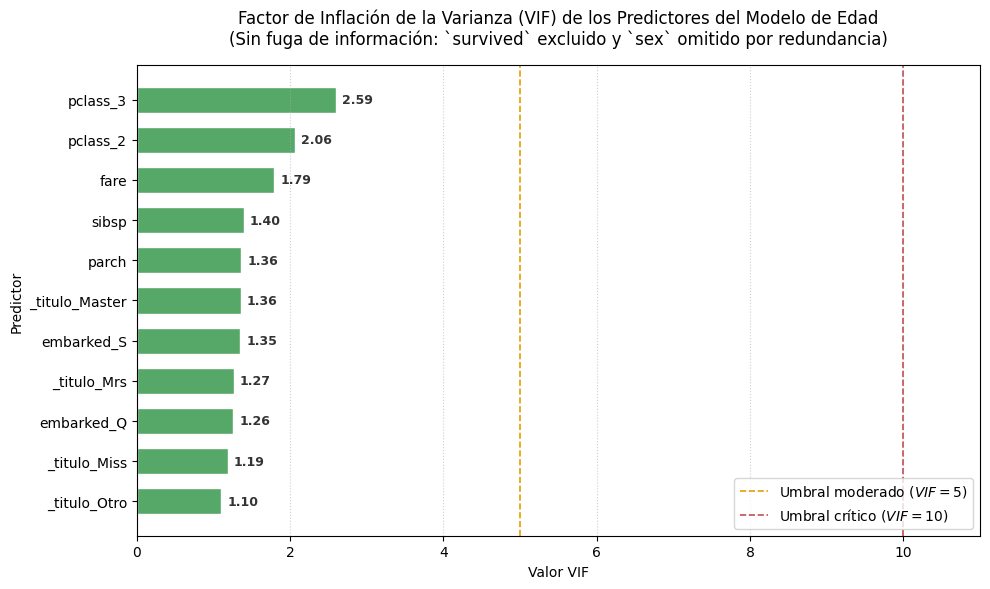

In [26]:
# Cálculo del VIF para todos los predictores en la matriz X sobre los datos observados
vif_series = pd.Series(index=X.columns, dtype=float)

for col in X.columns:
    other_cols = [c for c in X.columns if c != col]
    X_others = X.loc[observado, other_cols]
    y_col = X.loc[observado, col]
    r2_col = LinearRegression().fit(X_others, y_col).score(X_others, y_col)
    vif_series[col] = 1.0 / (1.0 - r2_col) if r2_col < 1.0 else np.inf

df_vif = vif_series.sort_values(ascending=True).reset_index()
df_vif.columns = ['Predictor', 'VIF']

print("Tabla de VIF por Predictor:")
print(df_vif.sort_values(by='VIF', ascending=False).to_string(index=False))

# --- Gráfico de Barras Horizontal del VIF ---------------------------------------
plt.figure(figsize=(10, 6))

colores = ['#55A868' if v < 5 else ('#E69F00' if v < 10 else '#C44E52') for v in df_vif['VIF']]

bars = plt.barh(df_vif['Predictor'], df_vif['VIF'], color=colores, edgecolor='white', height=0.65)

plt.axvline(5, color='#E69F00', linestyle='--', linewidth=1.2, label='Umbral moderado ($VIF = 5$)')
plt.axvline(10, color='#C44E52', linestyle='--', linewidth=1.2, label='Umbral crítico ($VIF = 10$)')

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.08, bar.get_y() + bar.get_height()/2, f'{w:.2f}',
             ha='left', va='center', fontsize=9, fontweight='bold', color='#333333')

plt.xlim(0, max(df_vif['VIF'].max() + 1.2, 11))
plt.title('Factor de Inflación de la Varianza (VIF) de los Predictores del Modelo de Edad\n(Sin fuga de información: `survived` excluido y `sex` omitido por redundancia)',
          fontsize=12, pad=15)
plt.xlabel('Valor VIF')
plt.ylabel('Predictor')
plt.legend(loc='lower right', frameon=True)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

---

## Nota sobre el flujo de trabajo

Este notebook es la versión **explicativa**: muestra el razonamiento detrás de cada decisión. Para el pipeline reproducible existe `clean.py`, que ejecuta exactamente esta misma lógica desde la terminal y escribe el resultado en disco:

```bash
python3 clean.py
```

Esa separación es deliberada. El notebook sirve para entender y justificar; el script sirve para ejecutar de forma repetible sin depender de que alguien corra las celdas en orden.